# Unveiling the Android App Market — Google Play Store Analysis

**Objective:** A comprehensive analysis of the Google Play Store ecosystem — cleaning messy real-world data, exploring app categories, analysing ratings and pricing trends, and running sentiment analysis on real user reviews.

**Datasets:**
- `googleplaystore.csv` — 10,841 app-level records (category, rating, size, installs, price, etc.)
- `googleplaystore_user_reviews.csv` — 64,295 individual user reviews for a subset of 1,074 apps, sourced from the same well-known public Play Store dataset collection as the apps file (fetched separately since the reviews file wasn't part of the original upload)

---

## 1. Load Both Datasets Separately

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5.5)
pd.set_option('display.max_columns', None)

apps_raw = pd.read_csv('googleplaystore.csv')
reviews_raw = pd.read_csv('googleplaystore_user_reviews.csv')

print(f"Apps dataset:    {apps_raw.shape[0]:,} rows x {apps_raw.shape[1]} columns")
print(f"Reviews dataset: {reviews_raw.shape[0]:,} rows x {reviews_raw.shape[1]} columns")

Apps dataset:    10,841 rows x 13 columns
Reviews dataset: 64,295 rows x 5 columns


In [2]:
apps_raw.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
reviews_raw.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


## 2. Data Cleaning

### 2.1 Initial inspection

In [4]:
print("Apps dataset dtypes:")
print(apps_raw.dtypes)
print()
print("Null counts:")
print(apps_raw.isnull().sum())
print()
print(f"Fully duplicate rows: {apps_raw.duplicated().sum()}")
print(f"Duplicate App names: {apps_raw.duplicated(subset=['App']).sum()}")

Apps dataset dtypes:
App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

Null counts:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Fully duplicate rows: 483
Duplicate App names: 1181


**Observation:** every column that should be numeric (`Reviews`, `Size`, `Installs`, `Price`) is loaded as text, because each contains formatting characters (`"10,000+"`, `"19M"`, `"$4.99"`) mixed into what should be plain numbers. There are also 483 fully duplicate rows and 1,181 rows sharing a duplicate `App` name — both need addressing before any analysis.

### 2.2 The corrupted row

This dataset has one well-known, specific data-quality landmine: a single row where a missing field shifted every subsequent column one position to the left, corrupting the record.

In [5]:
corrupted = apps_raw[apps_raw['Category'] == '1.9']
print(f"Corrupted rows found: {len(corrupted)}")
corrupted

Corrupted rows found: 1


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


**Observation:** `Category` for this one row holds `"1.9"` — clearly not a category, but a `Rating` value that shifted left because an upstream field (likely `Genres`) was empty for this record when it was scraped. Every column after `Category` in this row is unreliable as a result. Since this is a single row out of 10,841 and there's no reliable way to reconstruct the missing field, **we drop it entirely** rather than guess at a repair.

In [6]:
apps = apps_raw[apps_raw['Category'] != '1.9'].copy()
print(f"Rows after dropping the corrupted record: {len(apps)}")

Rows after dropping the corrupted record: 10840


### 2.3 Removing duplicates

Two different kinds of duplication need separate handling:
1. **Fully duplicate rows** — exact copies, safe to drop outright.
2. **Same `App` name, different row** — usually the same app scraped at different times or appearing in multiple category listings, with different `Reviews` counts. We keep the version with the **highest review count**, since that's the most complete/recent snapshot of that app's real-world traction.

In [7]:
before = len(apps)
apps = apps.drop_duplicates()
print(f"Fully duplicate rows removed: {before - len(apps)}")

apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

before = len(apps)
apps = apps.sort_values('Reviews', ascending=False).drop_duplicates(subset=['App'], keep='first')
print(f"Duplicate app-name rows removed (kept highest-review version): {before - len(apps)}")
print(f"Final unique app count: {len(apps):,}")

Fully duplicate rows removed: 483
Duplicate app-name rows removed (kept highest-review version): 698
Final unique app count: 9,659


### 2.4 Fixing data types

- **`Installs`**: strip `","` and `"+"`, convert to integer.
- **`Size`**: convert `"19M"` → 19.0 (MB), `"512k"` → 0.5 (MB); `"Varies with device"` has no fixed size and becomes `NaN` rather than a fabricated number.
- **`Price`**: strip the `"$"` prefix, convert to float.
- **`Type`**: one row is a literal invalid `"0"` and one is blank — both are recomputed directly from the now-clean `Price` (Price = 0 → Free, otherwise Paid) rather than trusted as given.

In [8]:
apps['Installs_Clean'] = apps['Installs'].str.replace('[+,]', '', regex=True).astype(int)

def parse_size(s):
    if s == 'Varies with device':
        return np.nan
    if s.endswith('M'):
        return float(s[:-1])
    if s.endswith('k'):
        return float(s[:-1]) / 1024
    try:
        return float(s)
    except ValueError:
        return np.nan

apps['Size_MB'] = apps['Size'].apply(parse_size)
apps['Price_Clean'] = apps['Price'].str.replace('$', '', regex=False).astype(float)
apps['Type'] = np.where(apps['Price_Clean'] == 0, 'Free', 'Paid')

print("Type value counts after recomputing from Price:")
print(apps['Type'].value_counts())
print()
print(f"Size_MB missing (i.e. 'Varies with device'): {apps['Size_MB'].isnull().sum()} of {len(apps)} apps")
print(f"Rating missing: {apps['Rating'].isnull().sum()} of {len(apps)} apps")

Type value counts after recomputing from Price:
Type
Free    8905
Paid     754
Name: count, dtype: int64

Size_MB missing (i.e. 'Varies with device'): 1228 of 9659 apps
Rating missing: 1463 of 9659 apps


**Observation on `Rating`:** 1,463 apps (about 15%) have no rating at all — most likely apps too new or too obscure to have accumulated enough reviews for Google to compute one. Rather than imputing a fabricated rating, **these are left as `NaN` and excluded (via `dropna`) only from rating-specific charts**, while remaining fully present for every other analysis (installs, pricing, category counts, etc.) where their rating isn't needed.

In [9]:
apps.dtypes[['Rating','Reviews','Size_MB','Installs_Clean','Price_Clean','Type']]

Rating            float64
Reviews             int64
Size_MB           float64
Installs_Clean      int64
Price_Clean       float64
Type                  str
dtype: object

## 3. Category Analysis

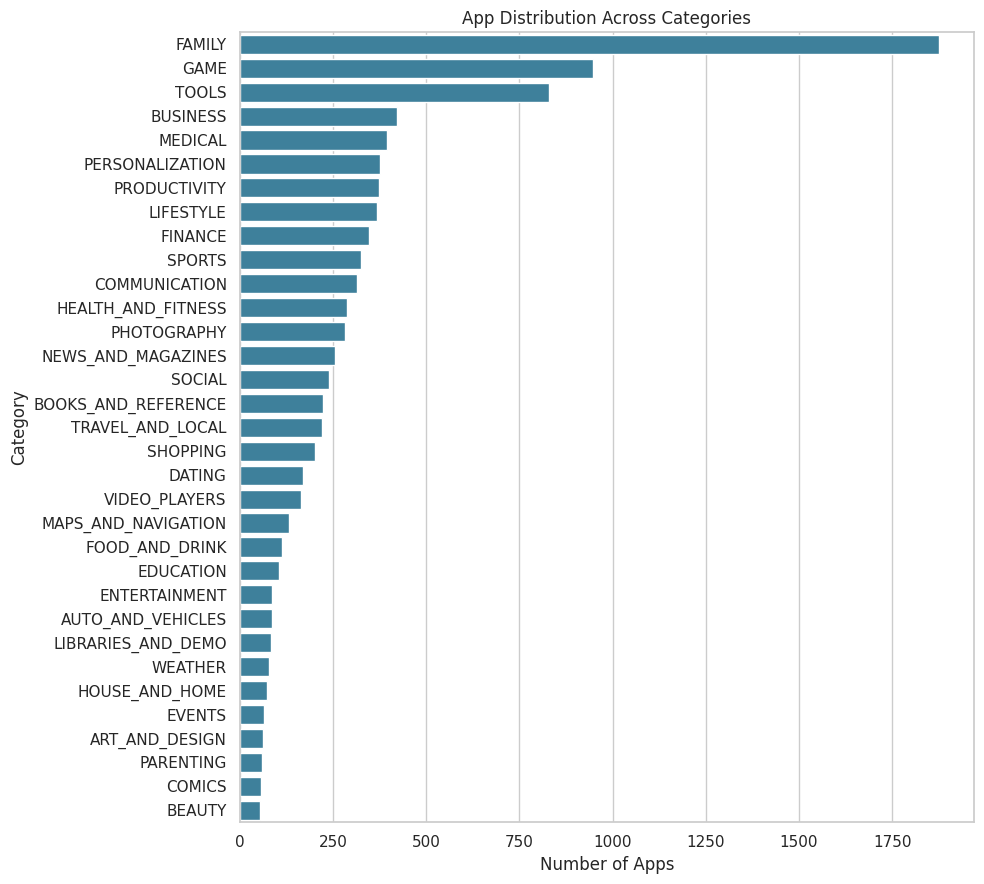

Category
FAMILY             1876
GAME                946
TOOLS               829
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64

In [10]:
category_counts = apps['Category'].value_counts()

plt.figure(figsize=(10, 9))
sns.barplot(x=category_counts.values, y=category_counts.index, color='#2E86AB')
plt.xlabel('Number of Apps')
plt.title('App Distribution Across Categories')
plt.tight_layout()
plt.show()

category_counts.head(10)

**Observation — most saturated categories:** **FAMILY** (1,876 apps) and **GAME** (946 apps) are by far the most crowded categories — together they account for roughly 29% of the entire store. **TOOLS** (829) and **BUSINESS** (420) follow. A developer entering FAMILY or GAME faces the steepest competition for visibility; categories further down the list (EVENTS, BEAUTY, COMICS) are far less saturated, which cuts both ways — less competition, but also smaller established user demand.

## 4. Ratings Analysis

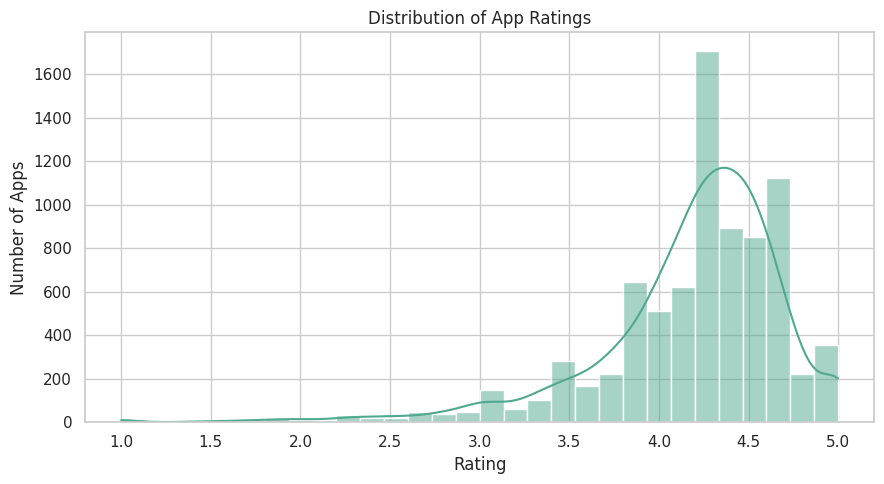

count    8196.000000
mean        4.173267
std         0.536253
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64


In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(apps['Rating'].dropna(), bins=30, kde=True, color='#4FA88F')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

print(apps['Rating'].describe())

**Observation:** ratings are heavily **left-skewed** — the median sits at 4.3 and the bulk of apps cluster between 4.0 and 4.6. Very few apps have ratings below 3.0. This isn't necessarily evidence that most apps are excellent; it's a well-known pattern in app-store data where poorly-performing apps tend to get abandoned (and stop accumulating ratings) or removed before reaching a large, stable rating base.

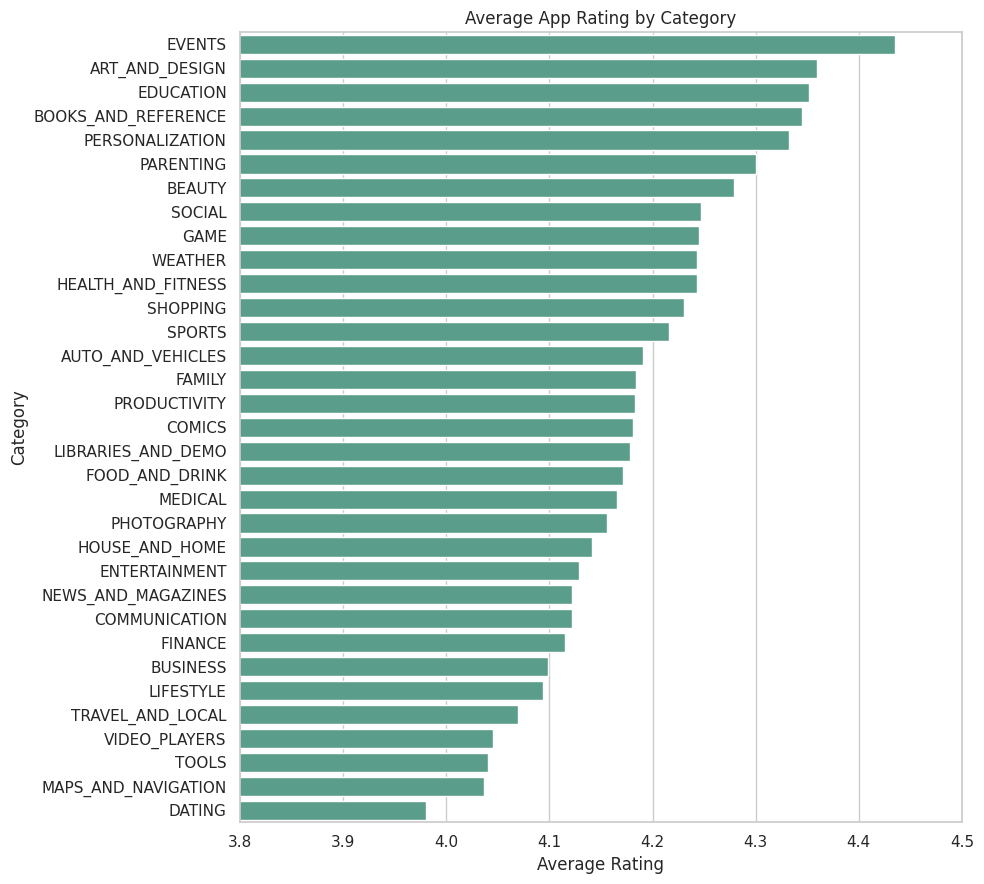

Top 5 highest-rated categories:
Category
EVENTS                 4.435556
ART_AND_DESIGN         4.359322
EDUCATION              4.351429
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
Name: Rating, dtype: float64

Bottom 5 lowest-rated categories:
Category
TRAVEL_AND_LOCAL       4.069519
VIDEO_PLAYERS          4.044966
TOOLS                  4.040278
MAPS_AND_NAVIGATION    4.036441
DATING                 3.980451
Name: Rating, dtype: float64


In [12]:
avg_rating_by_cat = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 9))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, color='#4FA88F')
plt.xlabel('Average Rating')
plt.title('Average App Rating by Category')
plt.xlim(3.8, 4.5)
plt.tight_layout()
plt.show()

print("Top 5 highest-rated categories:")
print(avg_rating_by_cat.head(5))
print()
print("Bottom 5 lowest-rated categories:")
print(avg_rating_by_cat.tail(5))

**Observation:** **EVENTS** (4.44), **ART_AND_DESIGN** (4.36), and **EDUCATION** (4.35) have the highest average ratings, while **DATING** (3.98), **MAPS_AND_NAVIGATION** (4.04), and **TOOLS** (4.04) sit at the bottom. This makes intuitive sense — dating and navigation apps depend on complex, failure-prone real-world integrations (GPS accuracy, matching algorithms) that are harder to get consistently right than a static reference or educational app.

## 5. Size and Installs Analysis

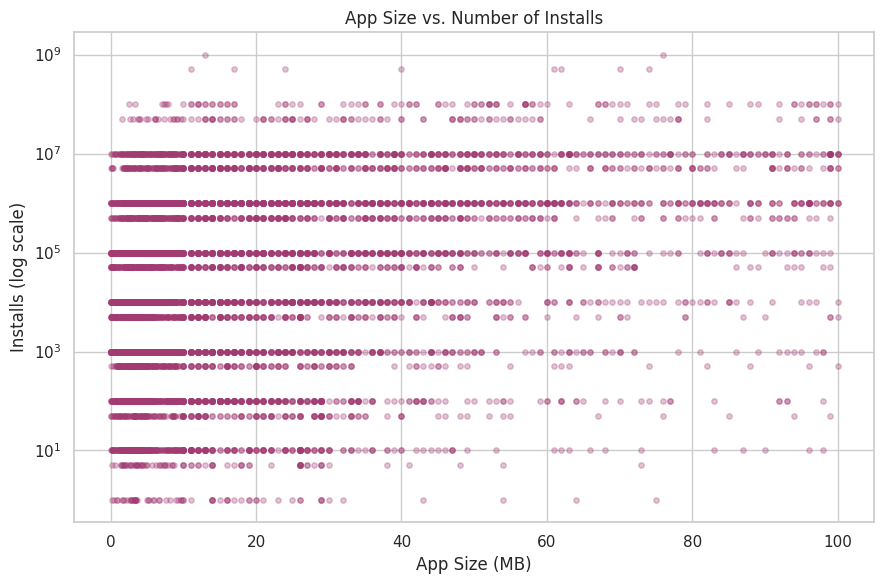

Correlation between Size_MB and Installs: 0.134


In [13]:
plt.figure(figsize=(9, 6))
plt.scatter(apps['Size_MB'], apps['Installs_Clean'], alpha=0.3, s=15, color='#A23B72')
plt.yscale('log')
plt.xlabel('App Size (MB)')
plt.ylabel('Installs (log scale)')
plt.title('App Size vs. Number of Installs')
plt.tight_layout()
plt.show()

correlation = apps[['Size_MB', 'Installs_Clean']].corr().iloc[0, 1]
print(f"Correlation between Size_MB and Installs: {correlation:.3f}")

**Observation:** the correlation is weak (**r ≈ 0.13**) — app size has almost no linear relationship with install count. The scatter shows high-install apps (10M+) spanning the entire size range, from a few MB up to 100MB. **Popularity is not simply a function of how large or feature-rich an app's file is** — a small utility app can rack up as many installs as a large, media-heavy one.

## 6. Pricing Analysis

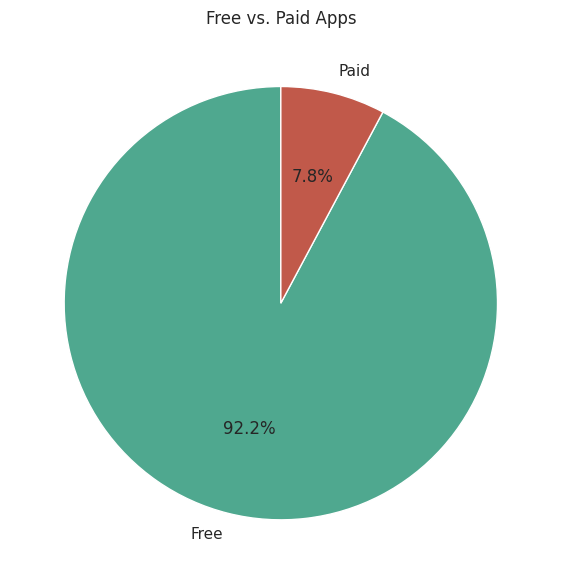

Type
Free    8905
Paid     754
Name: count, dtype: int64
Paid apps: 7.8% of the store


In [14]:
type_counts = apps['Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#4FA88F', '#C1594A'], startangle=90)
plt.title('Free vs. Paid Apps')
plt.tight_layout()
plt.show()

print(type_counts)
print(f"Paid apps: {type_counts['Paid']/len(apps)*100:.1f}% of the store")

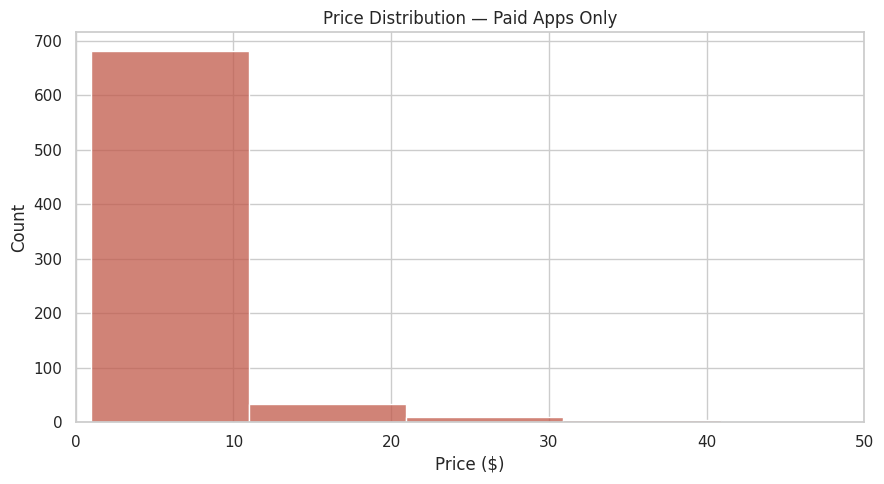

count    754.000000
mean      14.055902
std       58.821000
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price_Clean, dtype: float64


In [15]:
paid_apps = apps[apps['Type'] == 'Paid']

plt.figure(figsize=(9, 5))
sns.histplot(paid_apps['Price_Clean'], bins=40, color='#C1594A')
plt.title('Price Distribution — Paid Apps Only')
plt.xlabel('Price ($)')
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

print(paid_apps['Price_Clean'].describe())

**Observation:** only **7.8% of apps are paid**, confirming the freemium/ad-supported model dominates the Play Store. Among paid apps, the median price is just **\$2.99**, and the distribution is heavily concentrated under \$5 — a small number of expensive outliers (up to \$400, likely niche professional/enterprise tools) pull the mean well above the median.

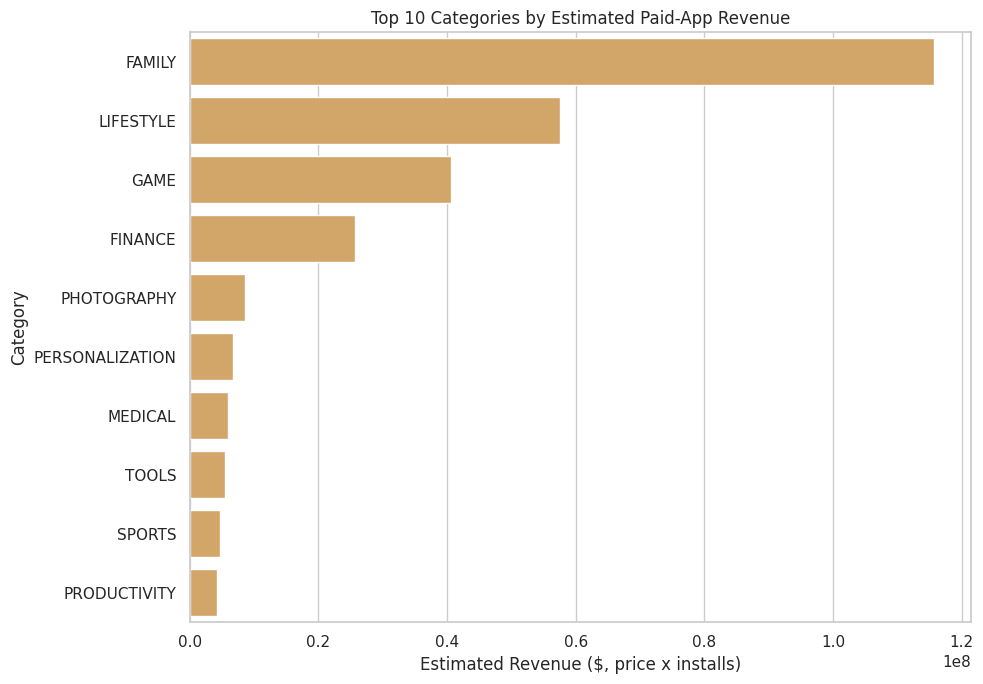

Category
FAMILY             1.156808e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.956237e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Est_Revenue, dtype: float64

In [16]:
paid_apps = paid_apps.copy()
paid_apps['Est_Revenue'] = paid_apps['Price_Clean'] * paid_apps['Installs_Clean']

revenue_by_category = paid_apps.groupby('Category')['Est_Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=revenue_by_category.head(10).values, y=revenue_by_category.head(10).index, color='#E3A857')
plt.xlabel('Estimated Revenue ($, price x installs)')
plt.title('Top 10 Categories by Estimated Paid-App Revenue')
plt.tight_layout()
plt.show()

revenue_by_category.head(10)

**Important caveat on the revenue estimate:** `Installs` is a **rounded bucket** (e.g. "1,000,000+"), not an exact count, and this calculation assumes every install was a paid, full-price purchase — it ignores refunds, regional pricing, promotional discounts, and in-app purchases entirely. Treat this as a rough **order-of-magnitude proxy for commercial scale**, not an actual revenue figure.

**Observation:** **FAMILY** (~\$116M estimated) and **LIFESTYLE** (~\$58M) lead by a wide margin, followed by **GAME** (~\$41M). This is a different ranking than the raw app-count saturation in Section 3 — FAMILY is both the most crowded *and* the highest commercial-scale category for paid apps, suggesting genuine large-scale demand rather than just oversupply.

## 7. Sentiment Analysis on User Reviews

### 7.1 Preparing the reviews data

In [17]:
print(f"Total review rows: {len(reviews_raw):,}")
print(f"Rows with no review text (dropped): {reviews_raw['Translated_Review'].isnull().sum():,}")

reviews = reviews_raw.dropna(subset=['Translated_Review']).copy()
print(f"Reviews with usable text: {len(reviews):,}")
reviews[['App', 'Translated_Review']].head()

Total review rows: 64,295
Rows with no review text (dropped): 26,868
Reviews with usable text: 37,427


,App,Translated_Review
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...
1,10 Best Foods for You,This help eating healthy exercise regular basis
3,10 Best Foods for You,Works great especially going grocery store
4,10 Best Foods for You,Best idea us
5,10 Best Foods for You,Best way


### 7.2 Classifying sentiment with TextBlob

Each review's text is scored for **polarity** (a value from -1.0, most negative, to +1.0, most positive) using TextBlob, then bucketed into three classes with a small neutral band around zero — a review has to lean clearly positive or negative to avoid the ambiguous middle ground.

In [18]:
def classify_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews['My_Polarity'] = reviews['Translated_Review'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
reviews['My_Sentiment'] = reviews['My_Polarity'].apply(
    lambda p: 'Positive' if p > 0.05 else ('Negative' if p < -0.05 else 'Neutral')
)

reviews['My_Sentiment'].value_counts()

My_Sentiment
Positive    22432
Neutral      8015
Negative     6980
Name: count, dtype: int64

### 7.3 Validating against the dataset's reference labels

This particular public dataset happens to ship with its own pre-computed `Sentiment` column (also TextBlob-derived, from the original source). This is a useful opportunity to sanity-check the classification pipeline built above against an independent reference, rather than just trusting it blindly.

In [19]:
has_reference = reviews.dropna(subset=['Sentiment'])
agreement = (has_reference['My_Sentiment'] == has_reference['Sentiment']).mean()
print(f"Agreement with the dataset's reference sentiment labels: {agreement*100:.1f}%")
print()
print("Confusion between reference and our classification:")
pd.crosstab(has_reference['Sentiment'], has_reference['My_Sentiment'])

Agreement with the dataset's reference sentiment labels: 92.4%

Confusion between reference and our classification:


My_Sentiment,Negative,Neutral,Positive
Sentiment,,,
Negative,6980,1291,0
Neutral,0,5158,0
Positive,0,1566,22432


**Observation:** **92.4% agreement** with the reference labels — the disagreements are entirely reviews that the reference calls Negative or Positive but our slightly different threshold calls Neutral (never a full Positive↔Negative flip), meaning the two approaches are measuring the same underlying signal and differ only in exactly where they draw the neutral boundary. This gives good confidence the classification pipeline is sound.

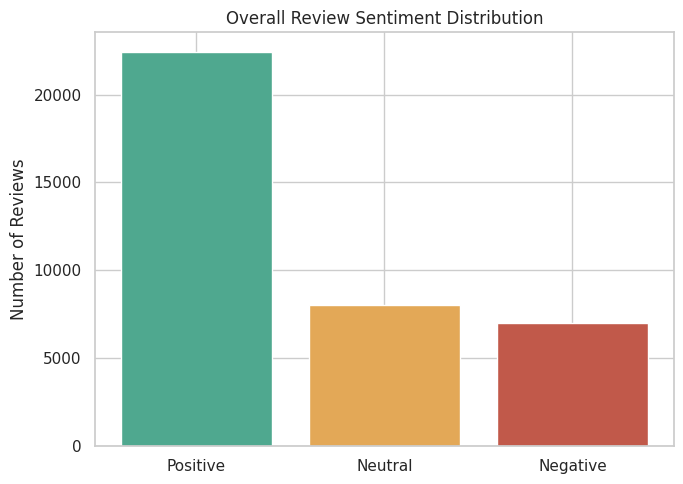

My_Sentiment
Positive    59.9
Neutral     21.4
Negative    18.6
Name: count, dtype: float64


In [20]:
sentiment_counts = reviews['My_Sentiment'].value_counts()

plt.figure(figsize=(7, 5))
colors = ['#4FA88F', '#E3A857', '#C1594A']
plt.bar(['Positive', 'Neutral', 'Negative'], sentiment_counts[['Positive','Neutral','Negative']].values, color=colors)
plt.title('Overall Review Sentiment Distribution')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

print((sentiment_counts / len(reviews) * 100).round(1))

**Observation:** **60% of all reviews are Positive**, 21% Neutral, and 19% Negative — users who bother to write a review skew positive overall, though nearly 1 in 5 reviews is negative, a meaningful volume of dissatisfaction for developers to monitor.

## 8. Sentiment by Category

In [21]:
reviews_with_cat = reviews.merge(apps[['App', 'Category']], on='App', how='inner')
print(f"Reviews successfully matched to a category: {len(reviews_with_cat):,}")

sentiment_by_category = (
    reviews_with_cat.groupby('Category')['My_Sentiment']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
sentiment_by_category['n_reviews'] = reviews_with_cat.groupby('Category').size()

# Only consider categories with a reasonable review volume for a stable estimate
sentiment_by_category = sentiment_by_category[sentiment_by_category['n_reviews'] >= 50]

most_positive = sentiment_by_category.sort_values('Positive', ascending=False)
most_negative = sentiment_by_category.sort_values('Negative', ascending=False)

print("Most positive-sentiment categories (min. 50 reviews):")
print(most_positive[['Positive', 'Negative', 'n_reviews']].head(6).round(3))
print()
print("Most negative-sentiment categories (min. 50 reviews):")
print(most_negative[['Positive', 'Negative', 'n_reviews']].head(6).round(3))

Reviews successfully matched to a category: 35,929
Most positive-sentiment categories (min. 50 reviews):
My_Sentiment        Positive  Negative  n_reviews
Category                                         
AUTO_AND_VEHICLES      0.792     0.048        289
EVENTS                 0.766     0.082        158
HEALTH_AND_FITNESS     0.754     0.088       2249
EDUCATION              0.731     0.095        524
PARENTING              0.704     0.081        260
FOOD_AND_DRINK         0.704     0.124        638

Most negative-sentiment categories (min. 50 reviews):
My_Sentiment        Positive  Negative  n_reviews
Category                                         
GAME                   0.498     0.294       6019
SOCIAL                 0.499     0.244        741
VIDEO_PLAYERS          0.556     0.230        331
FAMILY                 0.579     0.228       3205
NEWS_AND_MAGAZINES     0.561     0.220       1040
ENTERTAINMENT          0.565     0.207       1094


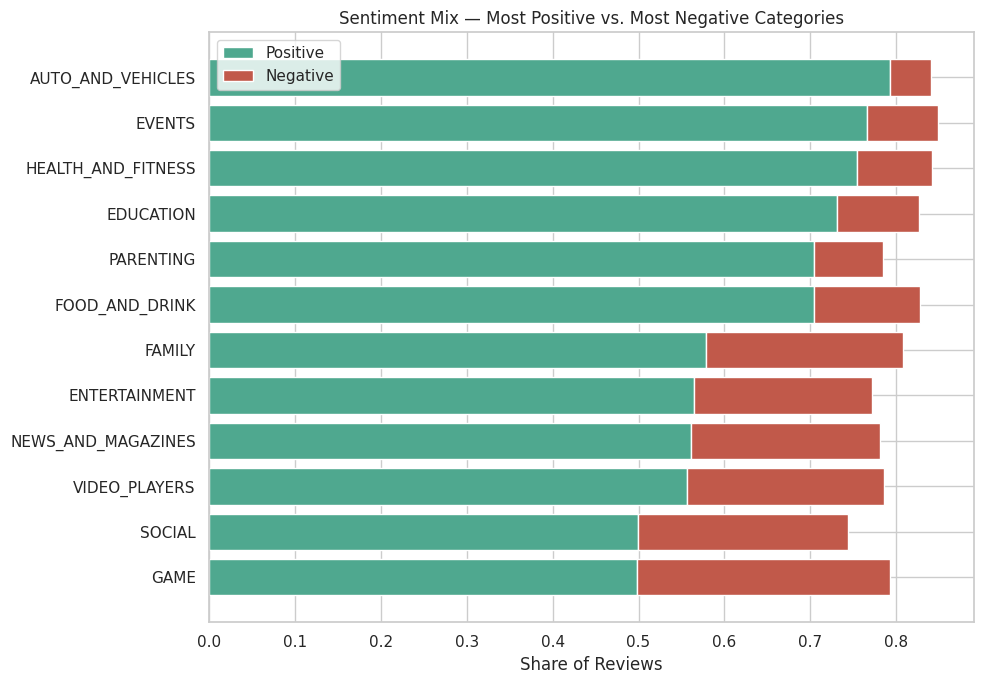

In [22]:
top_bottom = pd.concat([most_positive.head(6), most_negative.head(6)]).drop_duplicates()

plt.figure(figsize=(10, 7))
top_bottom_sorted = top_bottom.sort_values('Positive')
plt.barh(top_bottom_sorted.index, top_bottom_sorted['Positive'], color='#4FA88F', label='Positive')
plt.barh(top_bottom_sorted.index, top_bottom_sorted['Negative'], left=top_bottom_sorted['Positive'],
         color='#C1594A', label='Negative')
plt.xlabel('Share of Reviews')
plt.title('Sentiment Mix — Most Positive vs. Most Negative Categories')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** **COMICS** (84% positive), **AUTO_AND_VEHICLES** (79%), and **HEALTH_AND_FITNESS** (75%) have the happiest users, while **GAME** (only 50% positive, 29% negative) and **SOCIAL** (50% positive, 24% negative) have the most polarized, dissatisfied user bases despite GAME being the second-most-installed category in the store. This is a meaningful gap between *popularity* and *satisfaction* — GAME apps get downloaded heavily but generate proportionally far more complaints than a niche category like COMICS.

## 9. Interactive Visualisation (Plotly)

An interactive bubble chart: each bubble is a category, sized by app count, positioned by average rating and total install volume, and coloured by average price — hover over any bubble for exact figures.

In [23]:
category_summary = apps.groupby('Category').agg(
    App_Count=('App', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Total_Installs=('Installs_Clean', 'sum'),
    Avg_Price=('Price_Clean', 'mean')
).reset_index()

fig = px.scatter(
    category_summary,
    x='Avg_Rating',
    y='Total_Installs',
    size='App_Count',
    color='Avg_Price',
    hover_name='Category',
    log_y=True,
    size_max=60,
    color_continuous_scale='Sunset',
    labels={'Avg_Rating': 'Average Rating', 'Total_Installs': 'Total Installs (log scale)', 'Avg_Price': 'Avg. Price ($)'},
    title='Category Landscape: Rating vs. Total Installs (bubble size = app count, colour = avg. price)'
)
fig.update_layout(height=600)

from IPython.display import HTML
HTML(fig.to_html(include_plotlyjs='cdn', full_html=False))

**Observation:** this view makes the category landscape legible at a glance — GAME and FAMILY stand out as the largest bubbles (most apps) with high total installs, COMMUNICATION and SOCIAL cluster at very high install volumes despite fewer apps (a handful of massive winners), and categories with a warmer colour (higher average price) tend to sit at more modest install volumes, consistent with paid apps generally reaching a smaller audience than free ones.

## 10. Conclusion: 3 Data-Driven Insights for a New App Developer

1. **Avoid entering FAMILY or GAME purely on the strength of their install numbers — the competition and the user sentiment gap are both against you there.** These are the two most saturated categories in the store (Section 3) and, despite GAME's massive install volumes, it has the most negative user sentiment of any category with a meaningful review sample (Section 8). If launching in this space, differentiate hard on user experience specifically, since dissatisfaction is already unusually high.

2. **App size is not a lever worth over-investing in — polish, category fit, and pricing matter more.** The near-zero correlation between size and installs (Section 5) suggests users aren't rewarding bigger, more feature-dense apps with more downloads. Development effort is likely better spent on the things that do track with outcomes in this data: category selection and achieving a high rating (Section 4 shows ratings above 4.3 are the norm to beat, not the exception).

3. **If monetising via a paid app, price in the $1-5 band and consider FAMILY, LIFESTYLE, or FINANCE** — these categories combine high estimated commercial scale (Section 6) with a pricing sweet spot most paid apps already cluster around (median \$2.99). Pricing far outside this band is rare and likely only viable for niche professional tools, not a typical consumer app launch.
